# Pamela Huacca - Paula Andrea Cataño

In [ ]:
#SECUENCIAS DISCRETAS ELEMENTALES - IMPULSO, ESCALÓN Y RAMPA

import numpy as np
import matplotlib.pyplot as plt

# Impulso
def impseq(n0, n1, n2):
#   Genera x(n) = delta(n-n0); n1 <= n <= n2
#	 ----------------------------------------------
    n = np.arange(n1,n2+1) # Se crea el vector de muestras
    x = (n-n0) == 0 
    return [x,n]

# 1. Escalón unitario
def stepseq(n0, n1, n2):
#   Genera x(n) = u(n-n0); n1 <= n <= n2
    n = np.arange(n1,n2+1)
    x = (n-n0) >= 0
    return [x,n]

# 2. Rampa
def rampseq(n0, n1, n2):
#   Genera x(n) = (n-n0)*u(n-n0); n1 <= n <= n2
    n = np.arange(n1,n2+1)
    x = (n-n0) * ((n-n0) >= 0)
    return [x,n]

In [2]:
impseq1 = impseq(0, -5, 5)
stepseq1 = stepseq(0, -5, 5)
rampseq1 = rampseq(0, -5, 5)

[array([False, False, False, False, False,  True,  True,  True,  True,
        True,  True]), array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5])]


Text(0.5, 1.0, 'Escalón unitario')

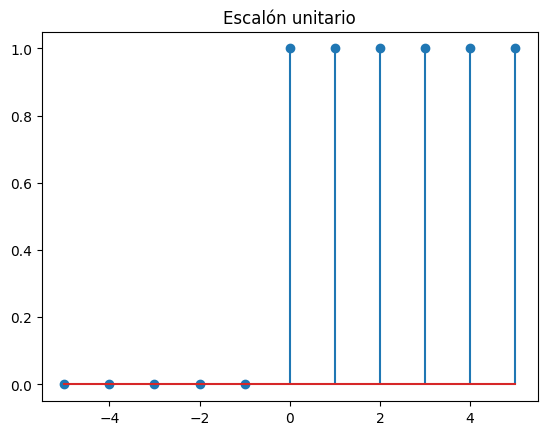

In [12]:
print(stepseq1)
plt.stem(stepseq1[1], stepseq1[0])
plt.title('Escalón unitario')

[array([0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5]), array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5])]


Text(0.5, 1.0, 'Rampa')

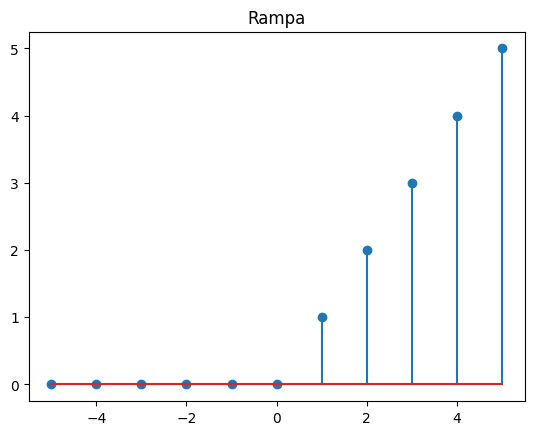

In [15]:
print(rampseq1)
plt.stem(rampseq1[1], rampseq1[0])
plt.title('Rampa')

Text(0, 0.5, 'X1[n]')

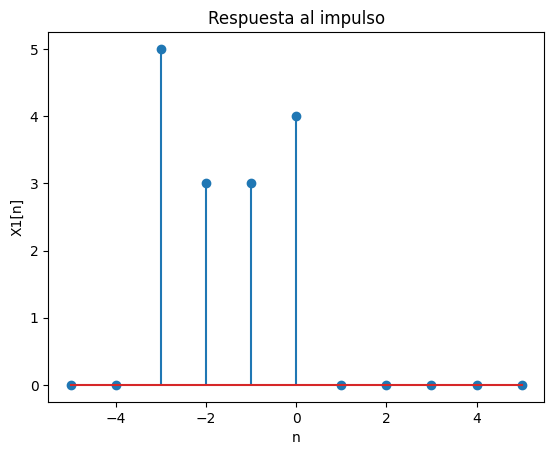

In [4]:
# PUNTO 3.a
n1 = -5
n2 = 5

x1, n = impseq(-1, n1, n2)   # δ[n+1]
x2, _ = impseq(-3, n1, n2)   # δ[n+3]
x3, _ = impseq(-2, n1, n2)   # δ[n+2]
x4, _ = impseq(0, n1, n2)    # δ[n]

X1 = 3*x1 + 5*x2 + 3*x3 + 3*x4 +x4

plt.stem(n, X1)
plt.title('Respuesta al impulso')
plt.xlabel('n')
plt.ylabel('X1[n]')

Text(0, 0.5, 'X2[n]')

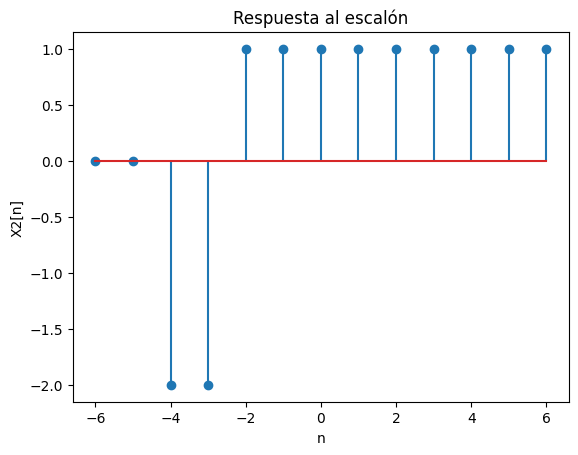

In [5]:
# PUNTO 3.b
n1 = -6
n2 = 6

x5, n = stepseq(-4, n1, n2)
x6, _ = stepseq(-2, n1, n2)

X2 = -2*x5 + 3*x6
    
plt.stem(n, X2)
plt.title('Respuesta al escalón')
plt.xlabel('n')
plt.ylabel('X2[n]')

Text(0, 0.5, 'X3[n]')

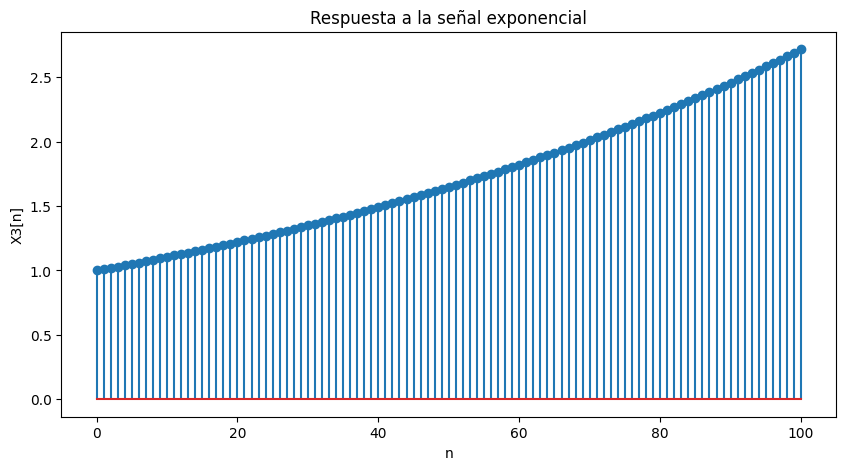

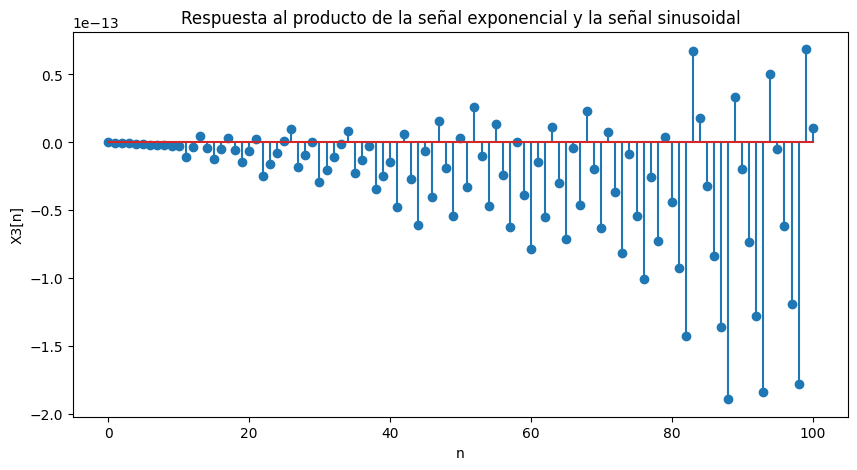

In [6]:
# Punto 3.c
n1 = 0
n2 = 100

X3_ = np.exp(0.01*np.arange(n1, n2+1))

plt.figure(figsize=(10, 5))
plt.stem(np.arange(n1, n2+1), X3_)
plt.title('Respuesta a la señal exponencial')
plt.xlabel('n')
plt.ylabel('X3[n]')


X3 = np.exp(0.01*np.arange(n1, n2+1)) * np.sin(2*np.pi*np.arange(n1, n2+1))
plt.figure(figsize=(10, 5))
plt.stem(np.arange(n1, n2+1), X3)
plt.title('Respuesta al producto de la señal exponencial y la señal sinusoidal')
plt.xlabel('n')
plt.ylabel('X3[n]')

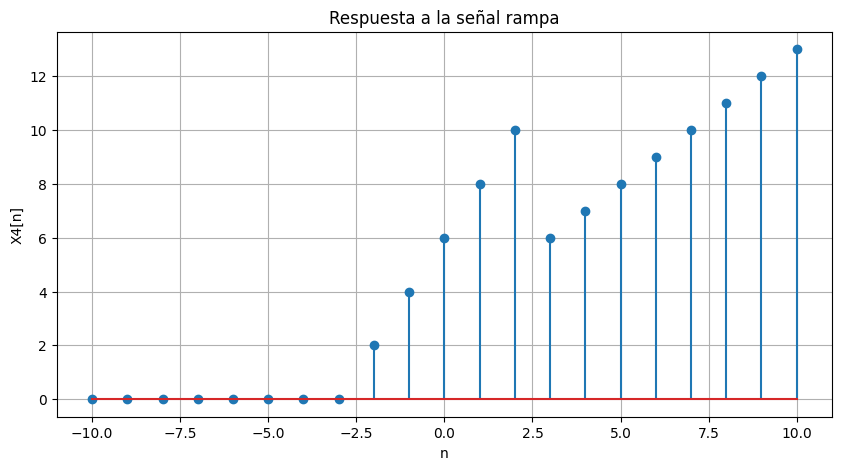

In [7]:
# Punto 3.d

n1 = -10
n2 = 10

x1,n = rampseq(-3, n1, n2)
x2, _ = rampseq(2, n1, n2)
x3, _ = stepseq(3, n1, n2)

X4  = 2*x1 - 1*x2 - 5*x3


plt.figure(figsize=(10, 5))
plt.stem(n, X4)
plt.title('Respuesta a la señal rampa')
plt.xlabel('n')
plt.ylabel('X4[n]')
plt.grid()

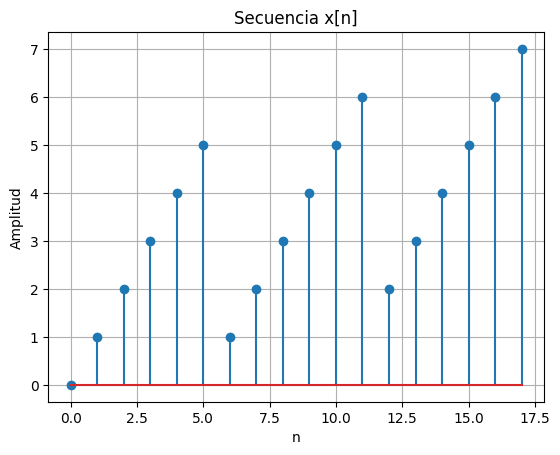

In [8]:
# PUNTO 4
n1 = 0
n2 = 17
n = np.arange(n1, n2+1)

x = np.zeros(len(n))

# 0 <= n <= 5
r1, _ = rampseq(0, n1, n2)
x[(n>=0) & (n<=5)]   = r1[(n>=0) & (n<=5)]

# 6 <= n <= 11
r2, _ = rampseq(5, n1, n2)
x[(n>=6) & (n<=11)]  = r2[(n>=6) & (n<=11)]

# 12 <= n <= 17
r3, _ = rampseq(10, n1, n2)
x[(n>=12)& (n<=17)]  = r3[(n>=12)& (n<=17)]

# 4.a derivada de x
dx = np.zeros(len(x))
dx[1:] = x[1:] - x[:-1]

plt.stem(n, x)
plt.title("Secuencia x[n]")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid()



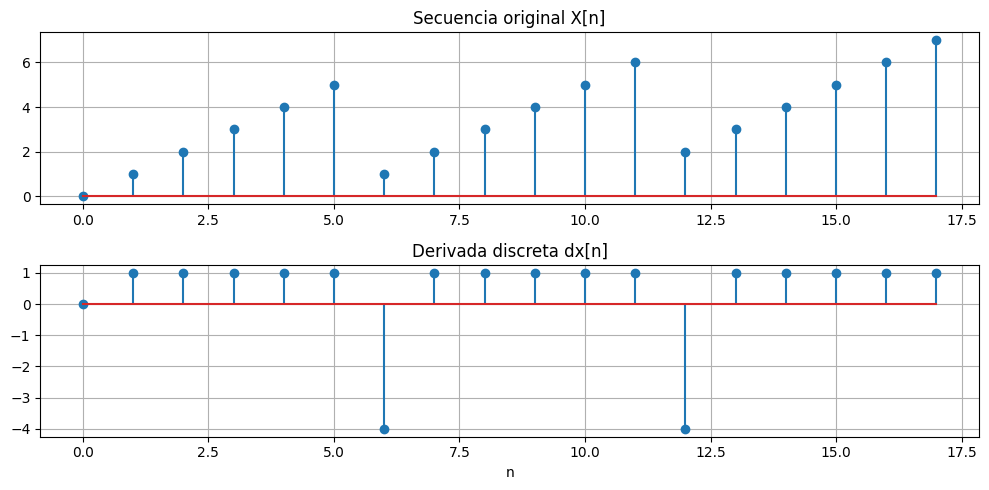

In [9]:
# PUNTO 4.b
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.stem(n, x)
plt.title("Secuencia original X[n]")
plt.grid()

plt.subplot(2,1,2)
plt.stem(n, dx)
plt.title("Derivada discreta dx[n]")
plt.xlabel("n")
plt.grid()

plt.tight_layout()

- ¿Qué se observa en la gráfica? En la mayor parte de la gráfica de la derivada el valor se mantiene constante en 1 y pasa en los tramos en los que la rampa crece, en cada paso que avanza en n, la amplitud crece una unidd. En los n=6 y n=12 la derivada tiene un pico negativo que coincide con el punto donde la señal cae.

- ¿Por qué no es exactamente la derivada del caso continuo? Porque al ser una señal discreta el no existen datos para todo el dominio del tiempo, en este casoel paso más pequeño posible es 1, por lo tanto, la derivada que se hace es una aproximación por diferencias finitas en las muestras.

In [10]:
# PUNTO 5 
x = np.array([0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10])
n0 = 5
n = np.arange(-n0, len(x)-n0)

print('vector x(n):\n', x)
print('dominio de n:\n', n)

vector x(n):
 [ 0  1  2  3  4  5  4  3  2  1  0  1  2  3  4  5  5  5  5 10 10 10 10]
dominio de n:
 [-5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


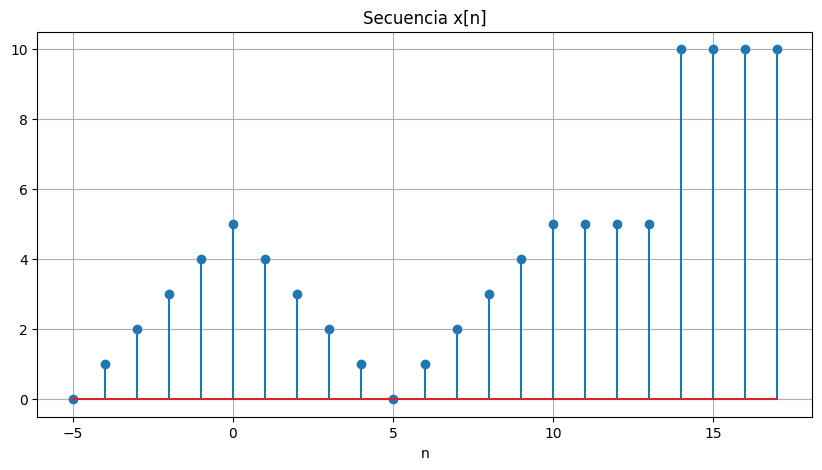

In [21]:
# Secuencia por tramos

# n de -5 a 0 y sube de 0 a 5
s1, n1 = rampseq(-5, -5, 0)

# n de 1 a 5 y baja de 4 a 0
s2, n2 = rampseq(0, 1, 5)
s2 = 5 - s2 

# n de 6 a 10 y sube de 1 a 5
s3, n3 = rampseq(5, 6, 10)

# n de 11 a 13 y es constante en 5
s4_base, n4 = stepseq(0, 11, 13) 
s4 = 5 * s4_base

# Tramo 5: n de 14 a 17 y es constante en 10
s5, n5 = stepseq(0, 14, 17)
s5 = 10 * s5

xn = np.concatenate((s1, s2, s3, s4, s5))
n_ = np.concatenate((n1, n2, n3, n4, n5))

plt.figure(figsize=(10,5))
plt.stem(n_, xn)
plt.title("Secuencia x[n]")
plt.xlabel("n")
plt.grid()

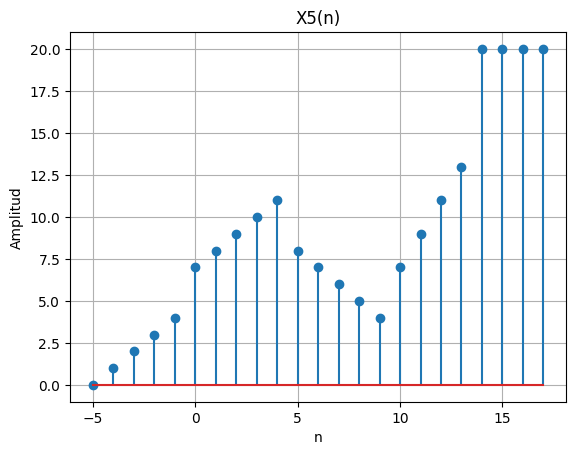

In [27]:
# PUNTO 5.a

x_n4 = np.zeros_like(x)

for i in range(len(n)):
    idx = n[i] - 4
    if idx in n:
        x_n4[i] = x[list(n).index(idx)]

X5 = 2*x_n4 + x

plt.stem(n, X5)
plt.title("X5(n)")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid()

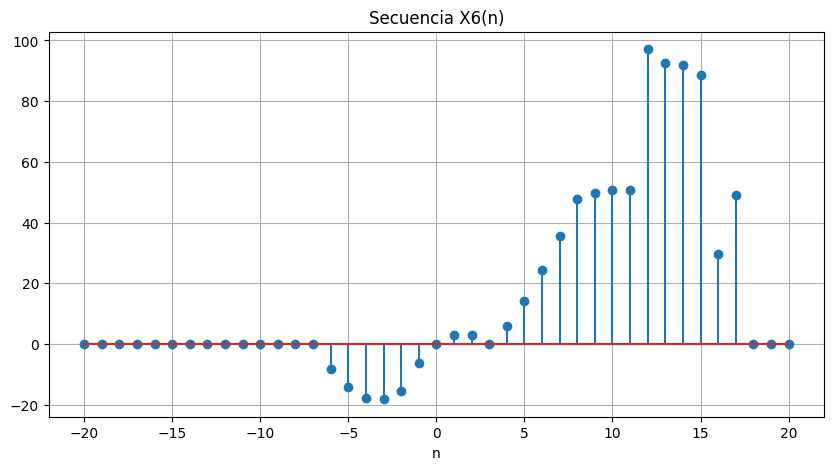

In [32]:
# PUNTO 5.b
n6 = np.arange(-20, 21)


x_n = np.zeros(len(n6))
x_n2 = np.zeros(len(n6)) 

for i in range(len(n6)):
    idx= n6[i]
    if idx in n:
        x_n[i] = x[list(n).index(idx)]
        
    idx_desplazado = n6[i] + 2
    if idx_desplazado in n:
        x_n2[i] = x[list(n).index(idx_desplazado)]

y = 0.001 * np.exp(0.5 * n6) * x_n
y_ = 10 * np.sin(0.05 * np.pi * n6) * x_n2

X6 = y + y_

plt.figure(figsize=(10,5))
plt.stem(n6, X6)
plt.title("Secuencia X6(n)")
plt.xlabel("n")
plt.grid()